# Fuzzy membership from spatial and social interactions

A worked example of the methodology in Kruse, Gao and Mayer (2025),
[*Modeling region affiliation with fuzzy membership based on spatial and social
interactions*](https://doi.org/10.1080/24694452.2025.2551044), *Annals of the
American Association of Geographers*.

The method measures how strongly each geographic area belongs to each region of
a plan, by quantifying the degree to which it is connected to all other areas
within that region. It runs here over the same study area as the paper: the
4,678 census block groups of Wisconsin, under the People's Maps Commission
congressional proposal.

> **The interaction data here is simulated.** The published results used human
> mobility flows from SafeGraph and social network connections from Meta's
> Social Connectedness Index, neither of which can be redistributed. This
> notebook substitutes a gravity model over the real block group centroids and
> populations, which reproduces the *qualitative* behaviour of the method but
> not the paper's numbers. Swap in your own interaction matrix and the rest of
> the workflow is unchanged.

## 1. The study area

`data/wi_cbgs_pmc_2020.gpkg` holds one row per block group: its GEOID, its 2020
population, the district the PMC plan assigns it to, and its geometry. Boundaries
are simplified to 300 m with shared edges preserved, so the file stays small
enough to ship.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from fuzzy_membership import (
    classify,
    combine,
    entropy,
    information_gain,
    interaction_membership,
    kl_divergence_by_region,
    region_membership,
)

# Works whether the notebook is run from the repo root or from examples/.
data_path = Path("data/wi_cbgs_pmc_2020.gpkg")
if not data_path.exists():
    data_path = Path("..") / data_path

cbgs = gpd.read_file(data_path).set_index("geoid")

# A few block groups have no residents, so the simulated interaction below gives
# them no interaction and no membership worth reading. The paper treats such
# areas as missing data, and they are dropped here for the same reason.
unpopulated = cbgs["population"] == 0
print(f"dropping {unpopulated.sum()} block groups with no population")
cbgs = cbgs[~unpopulated]

districts = cbgs["district"]
print(f"{len(cbgs):,} block groups, {districts.nunique()} districts, "
      f"{cbgs['population'].sum():,} people")
cbgs.drop(columns="geometry").head()

dropping 4 block groups with no population
4,674 block groups, 8 districts, 5,893,718 people


,population,district
geoid,,
550019501001,1136,5
550019501002,808,5
550019501003,634,5
550019501004,664,5
550019502011,675,5


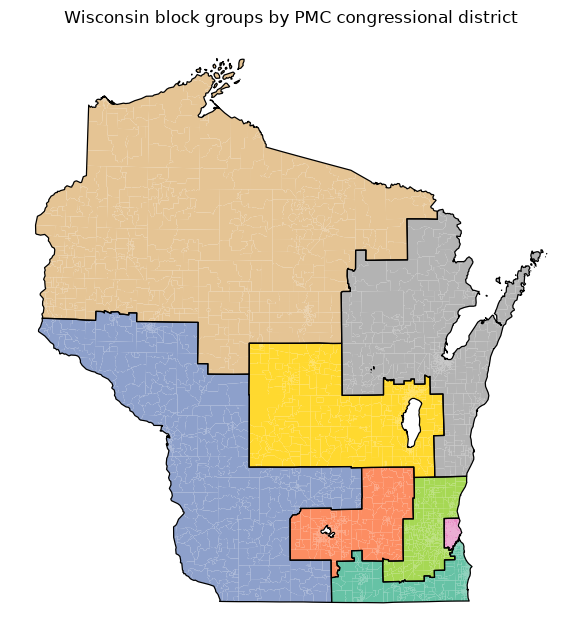

In [2]:
boundaries = cbgs.dissolve(by="district").boundary

fig, ax = plt.subplots(figsize=(6.5, 6.5))
cbgs.plot(column="district", cmap="Set2", linewidth=0, ax=ax)
boundaries.plot(ax=ax, color="black", linewidth=0.9)
ax.set_axis_off()
ax.set_title("Wisconsin block groups by PMC congressional district")
plt.tight_layout()
plt.show()

## 2. Interaction layers

The method needs a square matrix of interaction strength between areas. The
published results used human mobility flows and social network connections,
neither of which can be redistributed, so the two layers here are generated to
stand in for them: an adaptive-bandwidth Gaussian kernel over the block group
centroids, weighted by population, in which each area's bandwidth is its
distance to its *k*-th nearest neighbour. The spatial layer uses $k = 50$ and
the social layer $k = 400$, so the social layer reaches considerably further.

Substitute your own matrix here and the rest of the notebook is unchanged.

In [3]:
centroids = cbgs.geometry.centroid
xy = np.column_stack([centroids.x, centroids.y]).astype(np.float32)
mass = np.outer(cbgs["population"], cbgs["population"]).astype(np.float32)

distance = np.linalg.norm(xy[:, None, :] - xy[None, :, :], axis=-1)
np.fill_diagonal(distance, np.inf)   # an area's interaction with itself is undefined


def membership_for(k):
    """Memberships from a simulated interaction layer of reach k."""
    bandwidth = np.partition(distance, k, axis=1)[:, k][:, None]
    weights = np.exp(-((distance / bandwidth) ** 2))
    weights = (weights + weights.T) / 2 * mass
    memberships = interaction_membership(weights, districts.to_numpy())
    memberships.index = cbgs.index
    del weights                          # 4,678 x 4,678 float32 is 88 MB
    return memberships


spatial = membership_for(50)
social = membership_for(400)

spatial.head().round(4)

,0,1,2,3,4,5,6,7
geoid,,,,,,,,
550019501001,0.0,0.000,0.0126,0.0,0.0,0.9593,0.0026,0.0254
550019501002,0.0,0.000,0.0323,0.0,0.0,0.9553,0.0039,0.0085
550019501003,0.0,0.000,0.0314,0.0,0.0,0.9561,0.0051,0.0074
550019501004,0.0,0.000,0.0382,0.0,0.0,0.9494,0.0073,0.0052
550019502011,0.0,0.001,0.2086,0.0,0.0,0.7833,0.0040,0.0031


One row per block group, one column per district, and every row sums to 1 —
each area's interaction is fully accounted for across the eight districts.

Both layers are symmetric here, so `symmetrize` stays off. For directed data
such as origin-destination flows, pass `symmetrize=True` to fold in the
interaction arriving from the other direction.

## 3. Combining the two perspectives

Memberships from the two interaction types are combined element-wise and
renormalized:

$$\mu_{D_j}^{\text{combined}}(x) = \frac{\mu_{D_j}^{\text{spatial}}(x) \cdot \mu_{D_j}^{\text{social}}(x)}{\sum_{k} \mu_{D_k}^{\text{spatial}}(x) \cdot \mu_{D_k}^{\text{social}}(x)}$$

Where both perspectives agree, membership is amplified; where they disagree, it
is suppressed. `method="mean"` takes a weighted arithmetic mean instead, which
averages the perspectives without letting them reinforce each other — but note
that averaging cannot sharpen a membership, since entropy is concave. The
product is the rule used in the paper.

In [4]:
combined = combine(spatial, social, method="product")

# One block group, to show how the two perspectives resolve against each other.
example = spatial.max(axis=1).idxmin()
print(f"block group {example}")

pd.DataFrame({
    "spatial": spatial.loc[example],
    "social": social.loc[example],
    "combined (product)": combined.loc[example],
    "combined (mean)": combine(spatial, social, method="mean").loc[example],
}).rename_axis("district").round(4)

block group 551270005021


,spatial,social,combined (product),combined (mean)
district,,,,
0,0.3116,0.3351,0.3566,0.3233
1,0.3243,0.3104,0.3439,0.3174
2,0.0039,0.0350,0.0005,0.0195
3,0.0001,0.0671,0.0000,0.0336
4,0.3601,0.2431,0.2990,0.3016
5,0.0000,0.0065,0.0000,0.0033
6,0.0000,0.0006,0.0000,0.0003
7,0.0000,0.0023,0.0000,0.0011


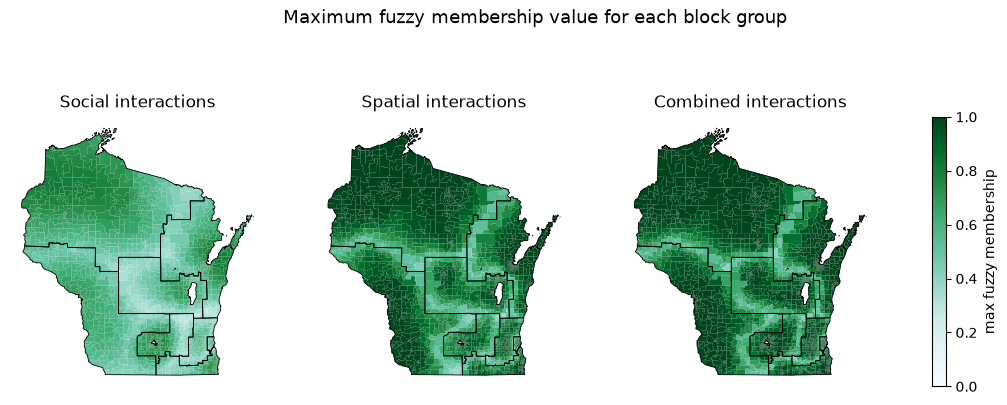

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (name, memberships) in zip(
    axes, [("Social", social), ("Spatial", spatial), ("Combined", combined)]
):
    cbgs.assign(v=memberships.max(axis=1)).plot(
        column="v", cmap="BuGn", vmin=0, vmax=1, linewidth=0, ax=ax
    )
    boundaries.plot(ax=ax, color="black", linewidth=0.6)
    ax.set_axis_off()
    ax.set_title(f"{name} interactions")

fig.suptitle("Maximum fuzzy membership value for each block group", fontsize=13)
fig.colorbar(
    plt.cm.ScalarMappable(cmap="BuGn", norm=plt.Normalize(0, 1)),
    ax=axes, shrink=0.7, label="max fuzzy membership",
)
plt.show()

Combining raises the maximum membership across most of the state, which is
the paper's finding that the two interaction types largely agree on which
district an area belongs to.

## 4. Entropy and information gain

Shannon entropy measures how dispersed an area's membership is across districts:

$$H(x) = -\sum_j \mu_{D_j}(x) \log_2 \mu_{D_j}(x)$$

Zero when an area sits wholly in one district, up to $\log_2 8 = 3$ bits when it
is split evenly across all eight. Information gain is the entropy an individual
perspective sheds when combined with the other.

In [6]:
pd.Series({
    "spatial": entropy(spatial).mean(),
    "social": entropy(social).mean(),
    "combined": entropy(combined).mean(),
}, name="mean entropy (bits)").round(3)

spatial     0.520
social      1.540
combined    0.362
Name: mean entropy (bits), dtype: float64

In [7]:
# Information gain is measured against the combined memberships, so the
# combined perspective is the reference rather than a third row.
pd.Series({
    "vs spatial": information_gain(spatial, combined).mean(),
    "vs social": information_gain(social, combined).mean(),
}, name="mean information gain from combining (bits)").round(3)

vs spatial    0.158
vs social     1.178
Name: mean information gain from combining (bits), dtype: float64

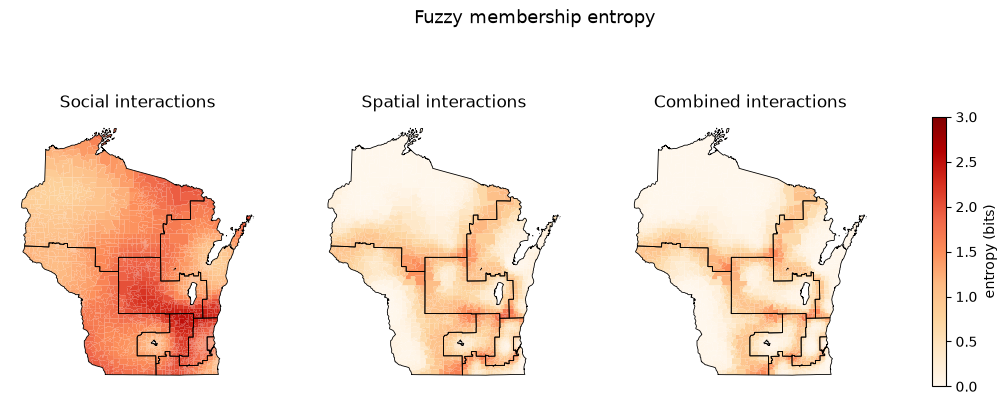

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (name, memberships) in zip(
    axes, [("Social", social), ("Spatial", spatial), ("Combined", combined)]
):
    cbgs.assign(v=entropy(memberships)).plot(
        column="v", cmap="OrRd", vmin=0, vmax=3, linewidth=0, ax=ax
    )
    boundaries.plot(ax=ax, color="black", linewidth=0.6)
    ax.set_axis_off()
    ax.set_title(f"{name} interactions")

fig.suptitle("Fuzzy membership entropy", fontsize=13)
fig.colorbar(
    plt.cm.ScalarMappable(cmap="OrRd", norm=plt.Normalize(0, 3)),
    ax=axes, shrink=0.7, label="entropy (bits)",
)
plt.show()

The social layer is the most dispersed, which follows directly from its
larger bandwidth: at $k = 400$ each area's interaction reaches well beyond its
own district. Combining lowers entropy across the state.

Entropy here rises towards the district boundaries, but that is a property of
this simulated interaction rather than of the method. The kernel depends on
distance alone, so an area's neighbours — and therefore its membership — only
shift where a district edge cuts between nearby areas. Real mobility and social
networks are shaped by employment, transport and history as much as by distance,
and can leave interior areas divided or boundary areas firmly attached.

## 5. Defuzzification

Assigning each area to the district it has the strongest membership in,

$$\text{District}(x) = \arg\max_j \mu_{D_j}(x)$$

and comparing that against the plan. **Misassigned** areas have their strongest
membership in a different district from the one the plan puts them in.
**Low-membership** areas are placed correctly but hold less than half of their
interaction with that district, so the affiliation is weak.

In [9]:
verdict = classify(combined, districts)
counts = verdict["status"].value_counts()
print(counts.to_string())

pd.crosstab(verdict["plan_region"], verdict["status"]).rename_axis("district")

status
aligned           4368
misassigned        279
low_membership      27


status,aligned,low_membership,misassigned
district,,,
0,573,3,21
1,462,1,21
2,485,2,88
3,691,4,8
4,485,12,37
5,562,1,46
6,617,2,13
7,493,2,45


/tmp/ipykernel_118553/2672974513.py:4: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  cbgs.assign(status=verdict["status"]).plot(


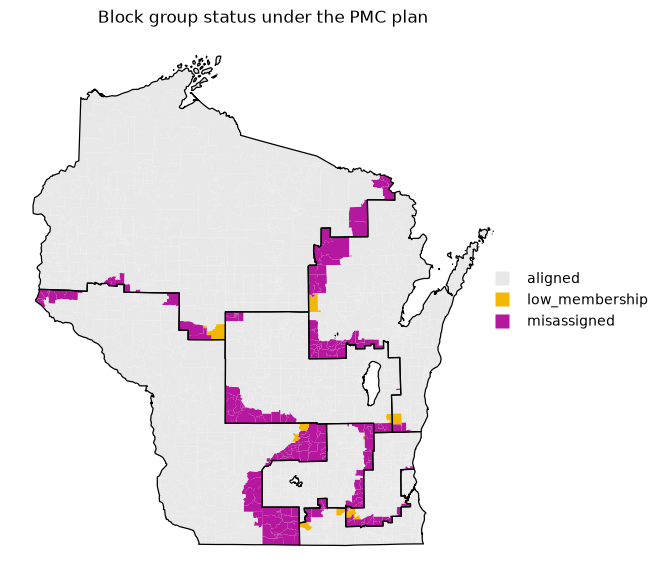

In [10]:
palette = {"aligned": "#e8e8e8", "low_membership": "#f2b705", "misassigned": "#b5179e"}

fig, ax = plt.subplots(figsize=(7, 7))
cbgs.assign(status=verdict["status"]).plot(
    column="status", color=[palette[s] for s in verdict["status"]], linewidth=0, ax=ax
)
boundaries.plot(ax=ax, color="black", linewidth=0.9)
ax.set_axis_off()
ax.set_title("Block group status under the PMC plan")
ax.legend(
    handles=[plt.Line2D([], [], marker="s", linestyle="", markersize=10,
                        markerfacecolor=c, markeredgecolor="none", label=s)
             for s, c in palette.items()],
    loc="center left", bbox_to_anchor=(0.92, 0.5), frameon=False,
)
plt.show()

Misassigned and low-membership areas fall along the district boundaries
here. That is a consequence of how this plan sits against this particular
interaction network, not a general rule: because the kernel is built on distance,
membership can only change where a district edge separates nearby areas.

With real mobility and social data the pattern need not look like this. A
district drawn across a commuting corridor or through a metropolitan area can
leave areas misassigned well inside it, while a boundary that follows a genuine
break in interaction may produce nothing remarkable at all. The map shows where
one plan sits awkwardly against one interaction network.

## 6. Divergence between perspectives

KL divergence compares the per-area entropy distributions district by district,
showing where one interaction type departs most from the combined view.
A higher divergence marks a district where that interaction type is most
distinct from the combined membership structure.

In [11]:
pd.DataFrame({
    "KL (social || combined)": kl_divergence_by_region(
        entropy(social), entropy(combined), districts
    ),
    "KL (spatial || combined)": kl_divergence_by_region(
        entropy(spatial), entropy(combined), districts
    ),
}).rename_axis("district").round(4)

,KL (social || combined),KL (spatial || combined)
district,,
0,1.2281,0.0568
1,0.2448,0.1178
2,1.2093,0.0374
3,0.5121,0.0532
4,0.6046,0.0749
5,0.2944,0.0580
6,1.2730,0.0577
7,0.9551,0.0686


## 7. District-level memberships

The same measure applies between whole districts rather than block groups.
`aggregate_interactions` collapses the area matrix into district totals, and
row-normalizing gives each district's membership in every other — a compact view
of which districts are most entangled with which.

In [12]:
bandwidth = np.partition(distance, 50, axis=1)[:, 50][:, None]
spatial_weights = np.exp(-((distance / bandwidth) ** 2))
spatial_weights = (spatial_weights + spatial_weights.T) / 2 * mass

between_districts = region_membership(spatial_weights, districts.to_numpy())
del spatial_weights

between_districts.rename_axis("district").round(3)

,0,1,2,3,4,5,6,7
district,,,,,,,,
0,0.872,0.018,0.011,0.045,0.054,0.000,0.000,0.000
1,0.013,0.856,0.084,0.000,0.033,0.013,0.000,0.000
2,0.010,0.105,0.770,0.000,0.000,0.030,0.084,0.000
3,0.046,0.000,0.000,0.832,0.121,0.000,0.000,0.000
4,0.046,0.039,0.000,0.097,0.805,0.004,0.000,0.009
5,0.000,0.017,0.032,0.000,0.004,0.838,0.023,0.086
6,0.000,0.000,0.094,0.000,0.000,0.025,0.862,0.019
7,0.000,0.000,0.000,0.000,0.009,0.078,0.016,0.896


## Using your own data

Replace the gravity model with a real interaction matrix. It must be square and
share an index with the district labels — a GEOID, a tract number, a name — and
cover the same areas in the same order:

```python
shared = matrix.index.intersection(districts.index)
matrix, districts = matrix.loc[shared, shared], districts.loc[shared]

memberships = interaction_membership(matrix, districts, symmetrize=True)
```

Memberships come back indexed by area, so they join straight back onto the
GeoDataFrame for mapping, exactly as above. See the
[README](../README.md) for loading matrices from saved arrays,
origin-destination tables, and pickled graphs.